# Klasifikasi Sawah vs Non-Sawah dengan Sentinel-2A (Random Forest)

Notebook ini mengerjakan:

- **50 sampel sawah** dan **50 sampel non-sawah** (poligon dari QGIS)
- **Klasifikasi 2 kelas**: `0 = non-sawah`, `1 = sawah`
- **Data Sentinel-2A (L2A) format GeoTIFF** dengan band B02, B03, B04, B08, B11, B12

Alur: baca citra → baca sampel → rasterisasi sampel → bagi latih/uji **per poligon** → latih Random Forest → evaluasi → peta hasil (TIF).

**File yang dibutuhkan** (upload ke Colab, atau taruh di folder yang sama dengan notebook):

| File | Isi |
|---|---|
| `GeoTIFF.tif` | Raster 6 band (urutan B02, B03, B04, B08, B11, B12) |
| `sawah.gpkg` | Poligon sampel sawah |
| `non_sawah.gpkg` | Poligon sampel non-sawah |

Format sampel boleh `.gpkg`, `.shp`, atau `.geojson`. Ubah nama file di sel **Pengaturan** bila berbeda.

## 1. Instalasi dan impor

In [ ]:
!pip -q install rasterio geopandas scikit-learn

In [ ]:
import os, warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio import features
from shapely.geometry import box
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             cohen_kappa_score, classification_report)

warnings.filterwarnings('ignore')

## 2. Pengaturan


In [ ]:
# --- File input ---
TIF_PATH      = 'GeoTIFF.tif'
SAWAH_PATH    = 'sawah.gpkg'
NONSAWAH_PATH = 'non_sawah.gpkg'

# --- File output ---
OUT_TIF  = 'klasifikasi_sawah.tif'
OUT_TXT  = 'hasil_evaluasi.txt'
OUT_PNG  = 'peta_klasifikasi.png'

# --- Parameter ---
N_SAMPEL    = 50      # jumlah poligon per kelas
PORSI_UJI   = 0.3     # 30% poligon untuk uji, 70% untuk latih
N_POHON     = 200     # jumlah pohon Random Forest
SEED        = 42

# --- Filter awan sederhana ---
# TIF dari Copernicus Browser tidak punya band awan (SCL), jadi dipakai ambang
# reflektansi: piksel yang terang di Blue, Green, dan Red dianggap awan.
# Set PAKAI_FILTER_AWAN = False untuk mematikannya.
PAKAI_FILTER_AWAN = True
BATAS_AWAN = 0.25

# Urutan band di TIF
NAMA_BAND = ['B02', 'B03', 'B04', 'B08', 'B11', 'B12']
KELAS = {0: 'non-sawah', 1: 'sawah'}

## 3. Upload file (khusus Google Colab)

Jalankan sel ini kalau file belum ada di Colab. Di komputer lokal, sel ini otomatis dilewati.

In [ ]:
perlu = [TIF_PATH, SAWAH_PATH, NONSAWAH_PATH]
kurang = [f for f in perlu if not os.path.exists(f)]

if kurang:
    try:
        from google.colab import files
        print('File belum ada:', kurang)
        print('Pilih file-nya (boleh banyak sekaligus)...')
        files.upload()
    except ImportError:
        pass

kurang = [f for f in perlu if not os.path.exists(f)]
assert not kurang, f'File masih belum ditemukan: {kurang}. Cek nama file di sel Pengaturan.'
print('Semua file ada:', perlu)

File belum ada: ['GeoTIFF.tif']
Pilih file-nya (boleh banyak sekaligus)...


Saving GeoTIFF.tif to GeoTIFF.tif
Saving non_sawah.gpkg to non_sawah (1).gpkg
Saving sawah.gpkg to sawah (1).gpkg
Semua file ada: ['GeoTIFF.tif', 'sawah.gpkg', 'non_sawah.gpkg']


## 4. Baca citra Sentinel-2A

Dari 6 band dihitung dua indeks tambahan:

- **NDVI** = (NIR − Red) / (NIR + Red), menunjukkan kerapatan vegetasi
- **MNDWI** = (Green − SWIR1) / (Green + SWIR1), menunjukkan air/genangan (penting untuk sawah)

In [ ]:
with rasterio.open(TIF_PATH) as src:
    X = src.read().astype('float32')
    transform, crs, profile = src.transform, src.crs, src.profile
    bounds = src.bounds
    nodata = src.nodata

nb, ny, nx = X.shape
assert nb == 6, f'Raster harus 6 band, ditemukan {nb}'

# Piksel tanpa data
tanpa_data = ~np.isfinite(X).all(axis=0)
if nodata is not None:
    tanpa_data |= (X == nodata).all(axis=0)
tanpa_data |= (X == 0).all(axis=0)

print(f'Ukuran citra: {nx} x {ny} piksel | CRS: {crs} | piksel tanpa data: {tanpa_data.mean()*100:.1f}%')
print('Rentang nilai tiap band (harus kira-kira 0 sampai 1 untuk reflektansi):')
for i, n in enumerate(NAMA_BAND):
    print(f'  {n}: min {np.nanmin(X[i]):.3f} | maks {np.nanmax(X[i]):.3f}')

eps = 1e-6
ndvi  = (X[3] - X[2]) / (X[3] + X[2] + eps)
mndwi = (X[1] - X[4]) / (X[1] + X[4] + eps)

F = np.concatenate([X, ndvi[None], mndwi[None]])
NAMA_FITUR = NAMA_BAND + ['NDVI', 'MNDWI']

# Filter awan sederhana
awan = np.zeros((ny, nx), dtype=bool)
if PAKAI_FILTER_AWAN:
    awan = (X[0] > BATAS_AWAN) & (X[1] > BATAS_AWAN) & (X[2] > BATAS_AWAN)
    print(f'Piksel terdeteksi awan: {awan.mean()*100:.1f}%')

Ukuran citra: 198 x 139 piksel | CRS: EPSG:32749 | piksel tanpa data: 0.0%
Rentang nilai tiap band (harus kira-kira 0 sampai 1 untuk reflektansi):
  B02: min 0.012 | maks 0.473
  B03: min 0.026 | maks 0.518
  B04: min 0.011 | maks 0.566
  B08: min 0.039 | maks 0.778
  B11: min 0.113 | maks 0.644
  B12: min 0.055 | maks 0.689
Piksel terdeteksi awan: 0.1%


## 5. Baca sampel poligon

Sampel dibaca, disamakan CRS-nya dengan citra, lalu diambil tepat `N_SAMPEL` poligon per kelas.

In [ ]:
def baca_sampel(path, label, nama):
    g = gpd.read_file(path).to_crs(crs)
    g = g[g.geometry.notna() & ~g.geometry.is_empty].copy()
    total = len(g)
    if total > N_SAMPEL:
        g = g.sample(N_SAMPEL, random_state=SEED)
    g = g[['geometry']].copy()
    g['kelas'] = label
    print(f'{nama}: {total} poligon di file -> dipakai {len(g)}')
    return g

g_non   = baca_sampel(NONSAWAH_PATH, 0, 'non-sawah')
g_sawah = baca_sampel(SAWAH_PATH, 1, 'sawah')

gdf = pd.concat([g_non, g_sawah], ignore_index=True)
gdf['pid'] = gdf.index + 1       # id unik per poligon

area_citra = box(bounds.left, bounds.bottom, bounds.right, bounds.top)
dalam = gdf.geometry.intersects(area_citra)
print(f'Poligon yang menyentuh area citra: {int(dalam.sum())} dari {len(gdf)}')
if dalam.sum() < len(gdf):
    print('PERINGATAN: ada poligon di luar citra. Poligon itu diabaikan otomatis.')

non-sawah: 50 poligon di file -> dipakai 50
sawah: 50 poligon di file -> dipakai 50
Poligon yang menyentuh area citra: 100 dari 100


## 6. Rasterisasi sampel ke grid citra

In [ ]:
def burn(kolom):
    return features.rasterize(
        ((geom, int(v)) for geom, v in zip(gdf.geometry, gdf[kolom])),
        out_shape=(ny, nx), transform=transform, fill=-1, dtype='int32')

kelas_r = burn('kelas')      # -1 = bukan sampel
pid_r   = burn('pid')

valid = (kelas_r >= 0) & ~tanpa_data & ~awan & np.isfinite(F).all(axis=0)

for k, n in KELAS.items():
    m = valid & (kelas_r == k)
    p = np.unique(pid_r[m])
    print(f'Kelas {k} ({n}): {len(p)} poligon terpakai, {int(m.sum())} piksel bebas awan')

assert valid.sum() > 0, 'Tidak ada piksel sampel di dalam citra. Cek CRS dan posisi poligon.'

Kelas 0 (non-sawah): 48 poligon terpakai, 79 piksel bebas awan
Kelas 1 (sawah): 50 poligon terpakai, 249 piksel bebas awan


## 7. Bagi data latih dan uji

Pembagian dilakukan **per poligon**, bukan per piksel. Kalau per piksel, piksel yang bertetangga bisa masuk ke latih dan uji sekaligus sehingga akurasi terlihat terlalu bagus.

In [ ]:
rng = np.random.default_rng(SEED)
id_uji = []
for k in KELAS:
    ids = np.unique(pid_r[valid & (kelas_r == k)])
    rng.shuffle(ids)
    n_uji = max(1, int(round(len(ids) * PORSI_UJI)))
    id_uji += list(ids[:n_uji])

is_uji = np.isin(pid_r, id_uji)
tr = valid & ~is_uji
te = valid & is_uji

n_poly_te = len(id_uji)
n_poly_tr = len(np.unique(pid_r[tr]))
print(f'Poligon training: {n_poly_tr} | testing: {n_poly_te}')
print(f'Piksel training: {int(tr.sum())} | testing: {int(te.sum())}')

X_tr, y_tr = F[:, tr].T, kelas_r[tr]
X_te, y_te = F[:, te].T, kelas_r[te]

Poligon training: 69 | testing: 29
Piksel training: 211 | testing: 117


## 8. Latih Random Forest

`class_weight='balanced'` dipakai karena jumlah piksel sawah biasanya jauh lebih sedikit daripada non-sawah.

In [ ]:
rf = RandomForestClassifier(
    n_estimators=N_POHON, class_weight='balanced',
    n_jobs=-1, random_state=SEED)
rf.fit(X_tr, y_tr)
print('Model selesai dilatih.')

Model selesai dilatih.


## 9. Evaluasi

In [ ]:
pred = rf.predict(X_te)

cm   = confusion_matrix(y_te, pred, labels=[0, 1])
oa   = accuracy_score(y_te, pred)
kappa = cohen_kappa_score(y_te, pred)
lap  = classification_report(y_te, pred, labels=[0, 1],
                             target_names=[KELAS[0], KELAS[1]], digits=3)

imp = sorted(zip(NAMA_FITUR, rf.feature_importances_), key=lambda t: -t[1])

teks = []
teks.append('Confusion matrix (baris=aktual, kolom=prediksi; urutan 0=non-sawah, 1=sawah):')
teks.append(str(cm))
teks.append(f'Overall Accuracy : {oa:.4f}')
teks.append(f'Kappa            : {kappa:.4f}')
teks.append(lap)
teks.append('Kepentingan fitur:')
for n, v in imp:
    teks.append(f'  {n:6s} {v:.3f}')
hasil_teks = '\n'.join(teks)
print(hasil_teks)

Confusion matrix (baris=aktual, kolom=prediksi; urutan 0=non-sawah, 1=sawah):
[[20  6]
 [ 8 83]]
Overall Accuracy : 0.8803
Kappa            : 0.6631
              precision    recall  f1-score   support

   non-sawah      0.714     0.769     0.741        26
       sawah      0.933     0.912     0.922        91

    accuracy                          0.880       117
   macro avg      0.823     0.841     0.831       117
weighted avg      0.884     0.880     0.882       117

Kepentingan fitur:
  B03    0.215
  B12    0.156
  B02    0.144
  MNDWI  0.144
  B11    0.110
  B08    0.099
  B04    0.066
  NDVI   0.065


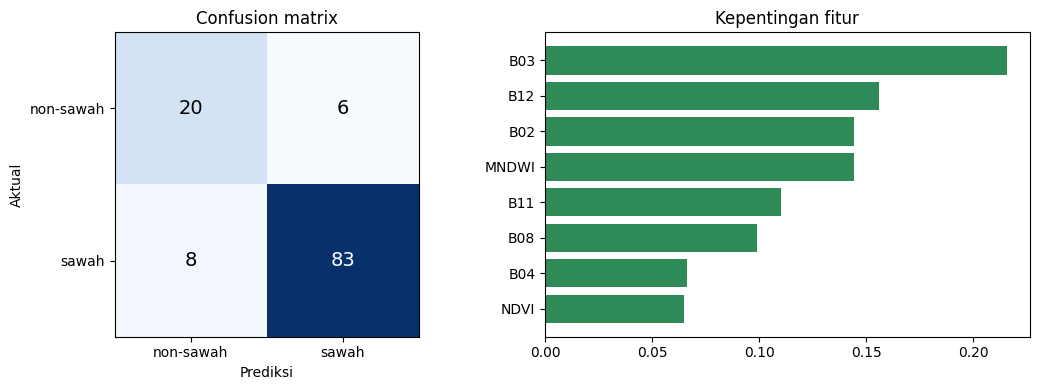

In [ ]:
# Confusion matrix dan kepentingan fitur dalam bentuk gambar
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

im = ax[0].imshow(cm, cmap='Blues')
ax[0].set_xticks([0, 1]); ax[0].set_yticks([0, 1])
ax[0].set_xticklabels([KELAS[0], KELAS[1]]); ax[0].set_yticklabels([KELAS[0], KELAS[1]])
ax[0].set_xlabel('Prediksi'); ax[0].set_ylabel('Aktual')
ax[0].set_title('Confusion matrix')
for i in range(2):
    for j in range(2):
        ax[0].text(j, i, int(cm[i, j]), ha='center', va='center',
                   color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)

nm, vl = zip(*imp)
ax[1].barh(nm[::-1], vl[::-1], color='#2e8b57')
ax[1].set_title('Kepentingan fitur')
plt.tight_layout()
plt.show()

## 10. Klasifikasi seluruh citra

Hasil disimpan sebagai GeoTIFF: `0 = non-sawah`, `1 = sawah`, `255 = tanpa data/awan`.

In [ ]:
flat = F.reshape(F.shape[0], -1).T
ok = np.isfinite(flat).all(axis=1)

hasil = np.full(flat.shape[0], 255, dtype='uint8')
hasil[ok] = rf.predict(flat[ok])
hasil = hasil.reshape(ny, nx)
hasil[tanpa_data] = 255
hasil[awan] = 255

profile.update(count=1, dtype='uint8', nodata=255, compress='lzw')
with rasterio.open(OUT_TIF, 'w', **profile) as dst:
    dst.write(hasil, 1)

luas_px = abs(transform.a * transform.e)
n_sawah = int((hasil == 1).sum()); n_non = int((hasil == 0).sum())
print(f'Tersimpan: {OUT_TIF}')
print(f'Sawah     : {n_sawah} piksel (~{n_sawah*luas_px/10000:.1f} ha)')
print(f'Non-sawah : {n_non} piksel (~{n_non*luas_px/10000:.1f} ha)')

Tersimpan: klasifikasi_sawah.tif
Sawah     : 11581 piksel (~453.9 ha)
Non-sawah : 15911 piksel (~623.6 ha)


## 11. Peta hasil

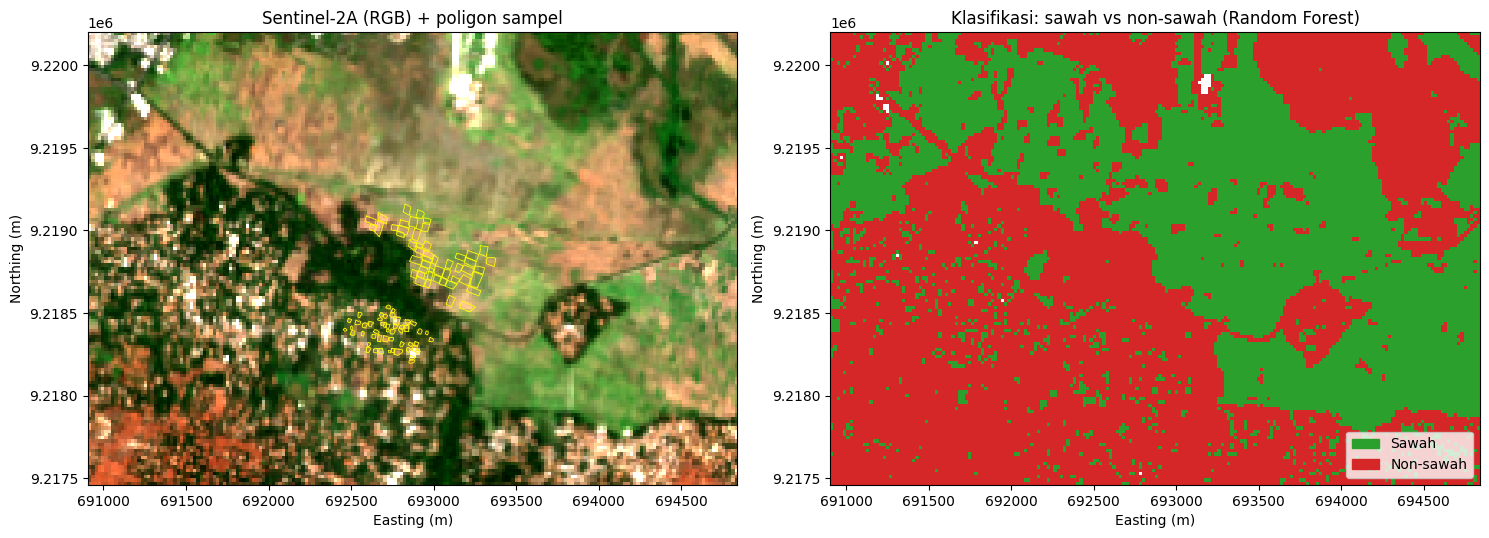

In [ ]:
# Citra warna asli (B04, B03, B02) dengan peregangan kontras
rgb = np.stack([X[2], X[1], X[0]], axis=-1)
lo, hi = np.nanpercentile(rgb[~tanpa_data], (2, 98))
rgb = np.clip((rgb - lo) / (hi - lo + eps), 0, 1)
rgb[tanpa_data] = 1

warna = ListedColormap(['#d62728', '#2ca02c'])   # 0 = merah (non-sawah), 1 = hijau (sawah)
peta = np.ma.masked_equal(hasil, 255)

fig, ax = plt.subplots(1, 2, figsize=(15, 6.5))
ext = [bounds.left, bounds.right, bounds.bottom, bounds.top]

ax[0].imshow(rgb, extent=ext)
gdf.boundary.plot(ax=ax[0], color='yellow', linewidth=0.6)
ax[0].set_title('Sentinel-2A (RGB) + poligon sampel')

ax[1].imshow(rgb, extent=ext, alpha=0.35)
ax[1].imshow(peta, cmap=warna, vmin=0, vmax=1, extent=ext, interpolation='nearest')
ax[1].set_title('Klasifikasi: sawah vs non-sawah (Random Forest)')
ax[1].legend(handles=[Patch(color='#2ca02c', label='Sawah'),
                      Patch(color='#d62728', label='Non-sawah')],
             loc='lower right')

for a in ax:
    a.set_xlabel('Easting (m)'); a.set_ylabel('Northing (m)')
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=150, bbox_inches='tight')
plt.show()

## 12. Simpan hasil evaluasi dan unduh

In [ ]:
sampel_info = [
    f'Citra: {nx} x {ny} piksel | CRS: {crs}',
    f'Poligon training: {n_poly_tr} | testing: {n_poly_te}',
    f'Piksel training: {int(tr.sum())} | testing: {int(te.sum())}',
    '',
]
with open(OUT_TXT, 'w', encoding='utf-8') as f:
    f.write('\n'.join(sampel_info) + hasil_teks)
print(f'Tersimpan: {OUT_TXT}')

try:
    from google.colab import files
    for f in [OUT_TIF, OUT_TXT, OUT_PNG]:
        files.download(f)
except ImportError:
    print('Bukan di Colab: ambil file hasil dari folder kerja.')

Tersimpan: hasil_evaluasi.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Catatan interpretasi

- **Overall Accuracy** = persentase piksel uji yang benar. **Kappa** = kesepakatan setelah memperhitungkan tebakan acak (di atas 0,8 sangat baik).
- **Recall sawah** = berapa persen sawah sebenarnya yang berhasil ditemukan. **Precision sawah** = berapa persen tebakan sawah yang memang sawah.
- Akurasi bisa terlihat terlalu tinggi bila poligon uji bersebelahan dengan poligon latih. Sebarkan sampel ke seluruh area, jangan hanya di satu gerombolan.
- Satu tanggal citra hanya menangkap satu fase tanam. Sawah yang sedang bera atau kering bisa mirip lahan kosong. Untuk hasil lebih baik gunakan beberapa tanggal.
- Filter awan di notebook ini hanya ambang reflektansi sederhana. Untuk hasil lebih rapi gunakan band SCL dari produk L2A.